In [29]:
import os
from dotenv import load_dotenv
load_dotenv("/home/jovyan/work/.env")
key = os.getenv("TIINGO_API_KEY")

In [30]:
import requests
import pandas as pd

In [31]:
url = "https://api.tiingo.com/tiingo/daily/AAPL/prices"
params = {
    "startDate": "2010-01-01",
    "endDate": "2025-12-31",
    "format": "json"
}
headers = {
    "Content-Type": "application/json",
    "Authorization": f"Token {key}"
}
response = requests.get(url, headers=headers, params=params)

if response.status_code != 200:
    raise Exception(response.text)

data = response.json()
df = pd.DataFrame(data)

df.head()

,date,close,high,low,open,volume,adjClose,adjHigh,adjLow,adjOpen,adjVolume,divCash,splitFactor
0,2010-01-04T00:00:00.000Z,214.01,214.50,212.38,213.43,17633200,6.412191,6.426872,6.363352,6.394812,493730093,0.0,1.0
1,2010-01-05T00:00:00.000Z,214.38,215.59,213.25,214.60,21496600,6.423276,6.459531,6.389419,6.429868,601905401,0.0,1.0
2,2010-01-06T00:00:00.000Z,210.97,215.23,210.75,214.38,19720000,6.321106,6.448744,6.314514,6.423276,552160552,0.0,1.0
3,2010-01-07T00:00:00.000Z,210.58,212.00,209.05,211.75,17040400,6.309420,6.351967,6.263578,6.344476,477131677,0.0,1.0
4,2010-01-08T00:00:00.000Z,211.98,212.00,209.06,210.30,15986100,6.351367,6.351967,6.263878,6.301031,447611247,0.0,1.0


In [32]:
df = df[["date", "close"]]
df["date"] = pd.to_datetime(df["date"])
df.set_index("date", inplace=True)

df.to_csv("AAPL.csv")
print("AAPL.csv saved successfully ✅")

AAPL.csv saved successfully ✅


In [33]:
df = pd.read_csv("AAPL.csv")
df.head()

,date,close
0,2010-01-04 00:00:00+00:00,214.01
1,2010-01-05 00:00:00+00:00,214.38
2,2010-01-06 00:00:00+00:00,210.97
3,2010-01-07 00:00:00+00:00,210.58
4,2010-01-08 00:00:00+00:00,211.98


In [34]:
df1 = df.reset_index()['close']

In [35]:
df1.shape

(4024,)

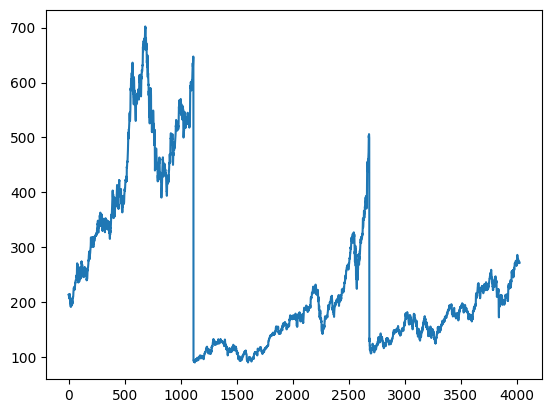

In [36]:
import matplotlib.pyplot as plt
plt.plot(df1)

In [37]:
import numpy as np

In [38]:
from sklearn.preprocessing import MinMaxScaler
scaler=MinMaxScaler(feature_range=(0,1))
df1=scaler.fit_transform(np.array(df1).reshape(-1,1))

In [39]:
df1.shape

(4024, 1)

In [40]:
training_size=int(len(df1)*0.65)
test_size=len(df1)-training_size
train_data,test_data=df1[0:training_size,:],df1[training_size:len(df1),:1]

In [41]:
training_size,test_size

(2615, 1409)

In [42]:
import numpy
def create_dataset(dataset, time_step=1):
	dataX, dataY = [], []
	for i in range(len(dataset)-time_step-1):
		a = dataset[i:(i+time_step), 0]   
		dataX.append(a)
		dataY.append(dataset[i + time_step, 0])
	return numpy.array(dataX), numpy.array(dataY)

In [43]:
time_step = 100
X_train, y_train = create_dataset(train_data, time_step)
X_test, ytest = create_dataset(test_data, time_step)

In [44]:
print(X_train.shape), print(y_train.shape)

(2514, 100)
(2514,)


(None, None)

In [45]:
print(X_test.shape), print(ytest.shape)

(1308, 100)
(1308,)


(None, None)

In [46]:
X_train =X_train.reshape(X_train.shape[0],X_train.shape[1] , 1)
X_test = X_test.reshape(X_test.shape[0],X_test.shape[1] , 1)

In [47]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM


In [48]:
model = Sequential()
model.add(LSTM(50, return_sequences=True, input_shape=(100,1)))
model.add(LSTM(50, return_sequences=True))
model.add(LSTM(50))
model.add(Dense(1))
model.compile(loss='mean_squared_error', optimizer='adam')

/opt/conda/lib/python3.11/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [49]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_3 (LSTM)                   │ (None, 100, 50)        │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_4 (LSTM)                   │ (None, 100, 50)        │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_5 (LSTM)                   │ (None, 50)             │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 50,851 (198.64 KB)

 Trainable params: 50,851 (198.64 KB)

 Non-trainable params: 0 (0.00 B)

In [51]:
model.fit(X_train,y_train,validation_data=(X_test,ytest),epochs=100,batch_size=64,verbose=1)

Epoch 1/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 16s 393ms/step - loss: 0.0024 - val_loss: 1.5959e-04
Epoch 2/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 16s 383ms/step - loss: 0.0022 - val_loss: 3.2319e-04
Epoch 3/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 9s 229ms/step - loss: 0.0026 - val_loss: 1.7681e-04
Epoch 4/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 10s 257ms/step - loss: 0.0019 - val_loss: 1.4129e-04
Epoch 5/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 10s 251ms/step - loss: 0.0018 - val_loss: 1.3022e-04
Epoch 6/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 13s 332ms/step - loss: 0.0017 - val_loss: 1.2467e-04
Epoch 7/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 19s 483ms/step - loss: 0.0017 - val_loss: 1.7010e-04
Epoch 8/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 20s 492ms/step - loss: 0.0015 - val_loss: 1.2301e-04
Epoch 9/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 19s 483ms/step - loss: 0.0014 - val_loss: 1.3354e-04
Epoch 10/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 17s 423ms/step - loss: 0.0012 - val_loss: 1.3097e-04
Epoch 11/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 16s 387ms/step - loss: 0.0012 - val_loss

In [52]:
import tensorflow as tf
tf.__version__

'2.20.0'

In [53]:
train_predict=model.predict(X_train)
test_predict=model.predict(X_test)

79/79 ━━━━━━━━━━━━━━━━━━━━ 12s 148ms/step
41/41 ━━━━━━━━━━━━━━━━━━━━ 4s 94ms/step


In [54]:
train_predict=scaler.inverse_transform(train_predict)
test_predict=scaler.inverse_transform(test_predict)

In [55]:
import math
from sklearn.metrics import mean_squared_error
math.sqrt(mean_squared_error(y_train,train_predict))

319.74317916569606

In [56]:
math.sqrt(mean_squared_error(ytest,test_predict))

182.28034169575557

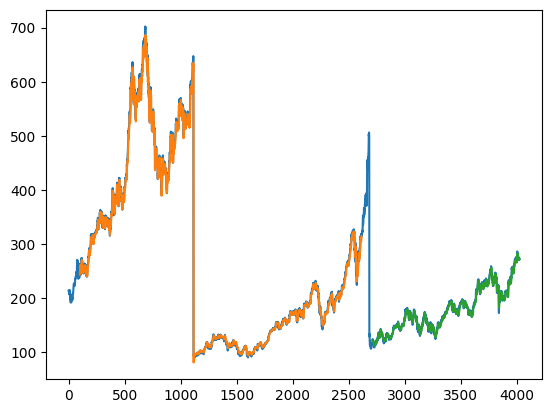

In [57]:
look_back=100
train_predictPlot = numpy.empty_like(df1)
train_predictPlot[:, :] = np.nan
train_predictPlot[look_back:len(train_predict)+look_back, :] = train_predict

test_predictPlot = numpy.empty_like(df1)
test_predictPlot[:, :] = numpy.nan
test_predictPlot[len(train_predict) + (look_back * 2)+1:len(df1)-1, :] = test_predict

plt.plot(scaler.inverse_transform(df1))
plt.plot(train_predictPlot)
plt.plot(test_predictPlot)
plt.show()

In [ ]:
len(test_data)

1409

In [58]:
x_input=test_data[1309:].reshape(1,-1)
x_input.shape

(1, 100)

In [59]:
temp_input=list(x_input)
temp_input=temp_input[0].tolist()

In [60]:
temp_input

[0.22375862181687423,
 0.22779575692197052,
 0.2338105978882678,
 0.23291164067863096,
 0.23096662417050767,
 0.22982249681278805,
 0.229283122487006,
 0.2218462946618286,
 0.22003203556601614,
 0.2247066130561276,
 0.22372593246379652,
 0.22724003791964958,
 0.22916870975123405,
 0.23255205779477622,
 0.23186558138014446,
 0.22791016965774247,
 0.24221176162923735,
 0.24435291425582684,
 0.24420581216697718,
 0.2412474257134451,
 0.2354777548952306,
 0.223121179431859,
 0.22841685463044686,
 0.23502010395214273,
 0.23931875388186064,
 0.24168873197999413,
 0.2430616848092576,
 0.2412474257134451,
 0.2537020692360498,
 0.27099473701415444,
 0.268297865385244,
 0.26483279395900755,
 0.2722859664607237,
 0.2699813670687457,
 0.268297865385244,
 0.268624758916021,
 0.2699650223922068,
 0.2727109280507338,
 0.2741656042626916,
 0.2719917622830244,
 0.27164852407570855,
 0.274230982968847,
 0.2676604230002288,
 0.25332614167565626,
 0.25723251936844166,
 0.2574123108103691,
 0.2599784250269

In [110]:
from numpy import array

lst_output=[]
n_steps=100
i = 0
while(i < 30):
    if(len(temp_input) > 100):
        x_input=np.array(temp_input[1:])
        print("{} day input {}".format(i,x_input))
        x_input=x_input.reshape(1,-1)
        x_input= x_input.reshape((1, n_steps, 1))
        yhat = model.predict(x_input, verbose=0)
        print("{} day output {}".format(i,yhat))
        temp_input.extend(yhat[0].tolist())
        temp_input=temp_input[1:]
        lst_output.extend(yhat.tolist())
        i=i+1
    else:
        x_input = x_input.reshape((1, n_steps,1))
        yhat = model.predict(x_input, verbose=0)
        print(yhat[0])
        temp_input.extend(yhat[0].tolist())
        print(len(temp_input))
        lst_output.extend(yhat.tolist())
        i=i+1
print(lst_output)

0 day input [0.17267787 0.17209056 0.17150675 0.17092636 0.17034946 0.16977596
 0.16920593 0.1686393  0.16807605 0.1675162  0.16695975 0.16640662
 0.16585681 0.16531037 0.16476719 0.16422735 0.16369078 0.16315749
 0.16262746 0.16210064 0.16157712 0.16105674 0.16053961 0.16002563
 0.15951486 0.15900722 0.15850273 0.15800139 0.15750311 0.15700799
 0.15651596 0.15602697 0.15554106 0.15505819 0.15457834 0.15410154
 0.15362772 0.15315689 0.15268907 0.15222414 0.15176222 0.15130322
 0.15084711 0.15039395 0.14994363 0.14949623 0.14905164 0.14860992
 0.14817104 0.14773497 0.14730173 0.14687125 0.14644355 0.14601862
 0.14559644 0.14517699 0.1447603  0.14434628 0.14393497 0.14352635
 0.14312039 0.14271706 0.14231639 0.14191833 0.1415229  0.14113003
 0.14073975 0.1403521  0.13996695 0.13958435 0.13920431 0.13882674
 0.13845173 0.13807914 0.13770905 0.13734141 0.13697623 0.13661349
 0.13625319 0.13589524 0.13553971 0.13518657 0.13483579 0.13448736
 0.13414128 0.13379751 0.13345608 0.13311695 0.132

In [111]:
day_new=np.arange(1,101)
day_pred=np.arange(101,131)

In [105]:
import matplotlib.pyplot as plt

In [106]:
len(df1)

4024

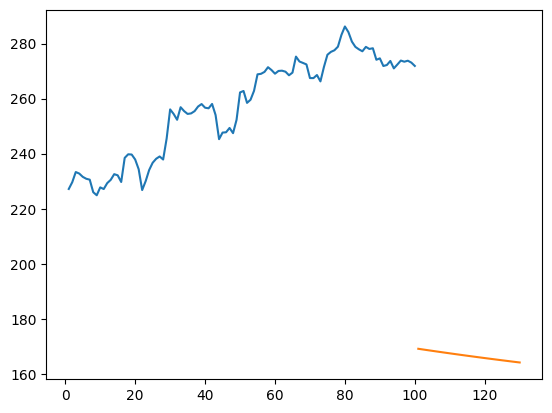

In [112]:
plt.plot(day_new,scaler.inverse_transform(df1[3924:]))
plt.plot(day_pred, scaler.inverse_transform(lst_output))

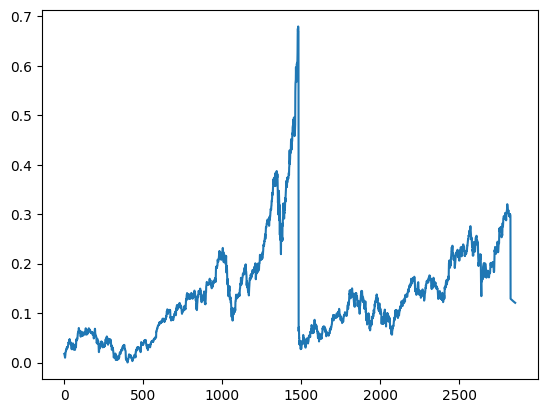

In [118]:
df3=df1.tolist()
df3.extend(lst_output)
plt.plot(df3[1200:])